# SVM Taxi Demand Prediction — Pooled Model

**One pooled SVM model per resolution, instead of one model per spatial unit.**

- Predicts taxi pickup demand (trip counts) per spatial unit per 4h time window.
- One model trained on all spatial units at once, spatial identity as a feature (fixed-effect
  dummies) — instead of fitting a separate model per unit.
- **Why pooled**: scales to hundreds of census tracts without refitting hundreds of models,
  and keeps the same panel-building/evaluation code reusable across resolutions.
- **Course constraint**: no lagged/autoregressive demand features — only exogenous time,
  weather, and spatial-identity inputs.

**Notebook structure**:
1. Data loading (1) & panel construction (2) & features (3)
2. Profile baseline (4)
3. Pooled `LinearSVR` — no kernel, feature importance, demand weighting (5)
4. Kernel comparison & hyperparameter tuning (6–7)
5. Results — model comparison, per-area performance (8)
6. Demand tiering & per-area models above a threshold (9)
7. Shortfalls & honest limitations (10)
8. Outlook: census tract level & other resolutions (11)

## Validation Strategy

- **Chronological holdout**: train 2024-01-01 – 2025-12-31, test 2026-01-01 – 2026-05-31.
- **`TimeSeriesSplit` (3 folds)** for all cross-validation / hyperparameter search.
- **Complete zero-filled grid** (every unit x every window) — models see genuine zero-demand
  windows, not just observed trips.
- **Profile baseline**: train-set mean demand per (hour, weekday) per unit — the reference
  model everything else is judged against.
- **Skill score** (the actual comparison metric): `1 - MAE_model / MAE_baseline`, per unit.
  - A ratio, so each unit's own demand scale cancels out — comparable across units of very
    different volume.
  - Aggregated two ways: **demand-weighted mean** (headline — matches the fleet-allocation
    use case) and **unweighted median** (guard rail — catches a model that only wins on a
    few big units).
- **Pooled R2/MAE/RMSE** (all rows at once) are a sanity check only, not the comparison
  metric — demand varies ~1000x across units, so pooled numbers are dominated by a handful
  of the busiest ones and hide poor performance elsewhere.

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import contextily as ctx

from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.svm import SVR, LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../data/chicago_weather_2024_2026_hourly.csv"
COMMUNITY_AREAS_PATH = "../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026
TRAIN_END = pd.Timestamp("2026-01-01")

FREQ = "4h"  # this draft: community-area resolution at 4h windows only
WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77 -- ALL of them, no threshold

# expm1(709) overflows float64; clip the log-scale prediction first so an unstable kernel
# (see the kernel comparison below) gets a very bad but finite score instead of crashing.
LOG_PRED_CAP = 20

# Chart colors (validated palette: sequential blue, diverging blue<->red)
SEQUENTIAL_BLUE = "#256abf"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#e34948", "#f0efec", "#2a78d6"])

# LinearSVR (liblinear) at some C values doesn't reach its optimum within max_iter on this
# data -- the fits are still valid (just not at the exact optimum), and raising max_iter
# further would not remove the warning either (liblinear's tolerance is effectively
# unreachable for these C/data combinations). Silenced rather than chasing an unreachable
# tolerance across hundreds of grid-search fits.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## 1. Data Loading

- Combined 2024–2026 taxi parquet (see `00_data_loading`) + hourly weather.
- Only pickup community area and trip timestamp needed for demand aggregation.

In [2]:
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)
print(f"Trips with pickup CA: {len(taxi):,} of {n_raw:,} ({len(taxi)/n_raw*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"Weather rows: {len(weather):,}")


Trips with pickup CA: 14,201,846 of 14,465,650 (98.2%)
Weather rows: 21,168


## 2. Building the Pooled Demand Panel

- Complete zero-filled area x window grid, all 77 areas (no demand threshold).
- Time features include a **second harmonic** for hour and day-of-week (captures the
  bimodal morning + evening rush pattern a single harmonic can't).
- Spatial identity: **community-area fixed effects** (one-hot dummies).

In [3]:
US_HOLIDAYS = pd.to_datetime([
    "2024-01-01", "2024-01-15", "2024-02-19", "2024-05-27",
    "2024-06-19", "2024-07-04", "2024-09-02", "2024-10-14",
    "2024-11-11", "2024-11-28", "2024-12-25",
    "2025-01-01", "2025-01-20", "2025-02-17", "2025-05-26",
    "2025-06-19", "2025-07-04", "2025-09-01", "2025-10-13",
    "2025-11-11", "2025-11-27", "2025-12-25",
    "2026-01-01", "2026-01-19", "2026-02-16", "2026-05-25",
])

window = taxi["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts = taxi.groupby(["pickup_community_area", window]).size().rename("count")

all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=FREQ, inclusive="left")
grid = pd.MultiIndex.from_product([ALL_AREAS, all_windows], names=["community_area", "timestamp"])
panel = counts.reindex(grid, fill_value=0).reset_index()

w = weather.copy()
w["timestamp"] = w["datetime"].dt.floor(FREQ)
w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
panel = panel.merge(w_agg, on="timestamp", how="left")

panel["hour"]        = panel["timestamp"].dt.hour
panel["day_of_week"] = panel["timestamp"].dt.dayofweek
month                = panel["timestamp"].dt.month

panel["hour_sin"]         = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"]         = np.cos(2 * np.pi * panel["hour"] / 24)
panel["hour_sin2"]        = np.sin(4 * np.pi * panel["hour"] / 24)   # 2nd harmonic (captures bimodal rush pattern)
panel["hour_cos2"]        = np.cos(4 * np.pi * panel["hour"] / 24)
panel["day_of_week_sin"]  = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos"]  = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_sin2"] = np.sin(4 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos2"] = np.cos(4 * np.pi * panel["day_of_week"] / 7)
panel["month_sin"]        = np.sin(2 * np.pi * month / 12)
panel["month_cos"]        = np.cos(2 * np.pi * month / 12)
panel["is_weekend"]       = (panel["day_of_week"] >= 5).astype(int)
panel["is_holiday"]       = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

# Community-area fixed effects (spatial identity)
dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
panel = pd.concat([panel, dummies], axis=1)

panel = panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel):,} rows ({panel['community_area'].nunique()} areas x "
      f"{panel['timestamp'].nunique():,} windows), {len(DUMMY_COLS)} area dummies, "
      f"zero-demand windows: {(panel['count']==0).mean()*100:.1f}%")

4h: 407,484 rows (77 areas x 5,292 windows), 76 area dummies, zero-demand windows: 18.9%


### 2.1 Why a Log-Scale Target

- Raw demand is heavily right-skewed: many low/zero windows, a long tail of high-demand ones.
- Median demand per area ranges from ~0 to 550+ per window — three orders of magnitude.
- `log1p(count)` is used as the regression target throughout (predictions back-transformed via
  clipped `expm1`), so squared-error loss isn't dominated by a handful of huge values.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(panel["count"], bins=60, color=SEQUENTIAL_BLUE)
axes[0].set_title("Raw demand")
axes[0].set_xlabel("Trips / 4h window")
axes[0].set_ylabel("Number of windows")

axes[1].hist(np.log1p(panel["count"]), bins=60, color=SEQUENTIAL_BLUE)
axes[1].set_title("log1p(demand)")
axes[1].set_xlabel("log1p(trips / 4h window)")

area_median_sorted = panel.groupby("community_area")["count"].median().sort_values()
axes[2].bar(range(len(area_median_sorted)), area_median_sorted.to_numpy(), color=SEQUENTIAL_BLUE, width=0.8)
axes[2].set_title("Median demand per area")
axes[2].set_xlabel("Community area (sorted)")
axes[2].set_ylabel("Median trips / 4h window")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Demand is heavily right-skewed and varies ~1000x across areas -> log1p target")
plt.tight_layout()
plt.show()

## 3. Feature Set & Shared Helpers

- 17 exogenous time/weather features + 76 community-area dummies.
- `ColumnTransformer` scales only the continuous features, not the dummies.

In [4]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]
ALL_COLS = FEATURE_COLS + DUMMY_COLS

preprocess = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])

train = panel[panel["timestamp"] < TRAIN_END]
test  = panel[panel["timestamp"] >= TRAIN_END]
y_true = test["count"].to_numpy(dtype=float)
print(f"train={len(train):,} rows   test={len(test):,} rows")


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


def predict_counts(model, X):
    """Back-transform log-scale predictions to counts, clipped at 0 (and capped pre-expm1
    so an unclipped kernel prediction can't overflow to inf)."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def per_area_results(test_df, y_pred, group_col="community_area"):
    """One row per spatial unit: MAE/R2/RMSE of the pooled model's predictions for that unit.
    `group_col` generalizes this across resolutions (community area now, census tract in
    section 11) so the same evaluation code is reused rather than duplicated per resolution."""
    tmp = pd.DataFrame({
        group_col: test_df[group_col].to_numpy(),
        "y_true": test_df["count"].to_numpy(dtype=float),
        "y_pred": y_pred,
    })
    rows = [
        {group_col: g, **metrics(g_df["y_true"], g_df["y_pred"])}
        for g, g_df in tmp.groupby(group_col)
    ]
    return pd.DataFrame(rows)


def skill_vs_baseline(results_df, baseline_df=None, group_col="community_area"):
    """Per-unit skill score: 1 - MAE_model / MAE_baseline -- comparable across units of different scale; MAE rather than RMSE so the
    baseline, which predicts the group mean, gets no built-in advantage under the scoring loss).
    `baseline_df` defaults to the community-area `baseline_results` for backward compatibility
    with the community-area cells above; pass the tract-level baseline explicitly at tract
    resolution (section 11)."""
    if baseline_df is None:
        baseline_df = baseline_results
    base = baseline_df[[group_col, "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on=group_col)
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


AREA_MEDIAN_DEMAND = panel.groupby("community_area")["count"].median().rename("median_demand")


def weighted_skill_vs_baseline(results_df, baseline_df=None, median_demand=None, group_col="community_area"):
    """Demand-weighted mean skill: each unit's skill weighted by its own median demand, so
    high-volume units -- where the fleet is actually deployed -- drive the number. This is the
    headline metric here (business case: the fleet is allocated mostly to high-demand areas).
    The unweighted median (every unit counted equally) is kept as a secondary spatial-coverage
    view.
    `baseline_df`/`median_demand` default to the community-area globals for backward
    compatibility; pass the tract-level equivalents explicitly at tract resolution (section 11).
    """
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    skill = skill_vs_baseline(results_df, baseline_df=baseline_df, group_col=group_col)
    weights = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return float(np.average(skill.to_numpy(), weights=weights))


def relative_mae(results_df, median_demand=None, group_col="community_area"):
    """MAE normalized by each unit's own median demand (+1, avoids div-by-zero for
    zero-median units) -- an absolute, baseline-free error scale, complementary to skill
    (which is relative to the profile baseline, not to the unit's own demand level). Unlike
    row-level MAPE this can't blow up on zero-demand rows, since it ratios the aggregate MAE
    to the aggregate median, not individual predictions to individual actuals.
    `median_demand` defaults to `AREA_MEDIAN_DEMAND` for backward compatibility; pass the
    tract-level lookup explicitly at tract resolution."""
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    demand = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return pd.Series(results_df["mae"].to_numpy() / (demand + 1), index=results_df.index, name="relative_mae")


def print_pooled_results(label, pooled_metrics, per_area_df, baseline_df=None, median_demand=None, group_col="community_area"):
    w_skill = weighted_skill_vs_baseline(
        per_area_df, baseline_df=baseline_df, median_demand=median_demand, group_col=group_col,
    )
    print(label)
    print(f"  Pooled  : R2={pooled_metrics['r2']:.3f}  MAE={pooled_metrics['mae']:.2f}  "
          f"RMSE={pooled_metrics['rmse']:.2f}")
    print(f"  Per area: demand-weighted skill (headline)={w_skill:+.3f}  "
          f"unweighted median skill={per_area_df['skill'].median():+.3f}  "
          f"median R2={per_area_df['r2'].median():.3f}  "
          f"(areas with negative skill: {(per_area_df['skill']<0).sum()} of {len(per_area_df)})")

train=337,722 rows   test=69,762 rows


### 3.1 Feature Correlations

- Sanity check before modeling: no pair of the 17 continuous features is near-collinear
  (hour/day-of-week sin-cos pairs are orthogonal by construction).

In [ ]:
corr = train[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6,
                color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature correlation matrix (train set)")
plt.tight_layout()
plt.show()

## 4. Profile Baseline

- Train-set mean demand per (hour, weekday), computed per area — every area gets its own
  baseline/skill reference, no exclusion.

Profile baseline, all 77 areas (0s)
  Pooled  : R2=0.933  MAE=9.52  RMSE=37.30
  Per area: median R2=0.304  median MAE=1.99  median RMSE=2.59  (areas with R2<0: 14 of 77)

Per-area profile-baseline performance (sorted by R2, worst first):
 community_area  median_demand      r2    mae   rmse
             53            7.0 -1.1816   4.20   5.17
             54            2.0 -0.9647   1.68   2.14
             55            1.0 -0.8154   1.27   1.63
             52            1.0 -0.7605   1.18   1.51
             37            3.0 -0.7501   2.21   2.64
             50            3.0 -0.2083   2.03   2.59
             75            4.0 -0.1643   2.49   3.17
              9            0.0 -0.1027   0.66   0.82
             12            3.0 -0.0919   1.72   2.13
             62            1.0 -0.0478   0.65   0.79
             56           72.0 -0.0363  29.94  37.96
             20            0.0 -0.0308   0.56   0.76
             63            0.0 -0.0134   0.39   0.54
             74    

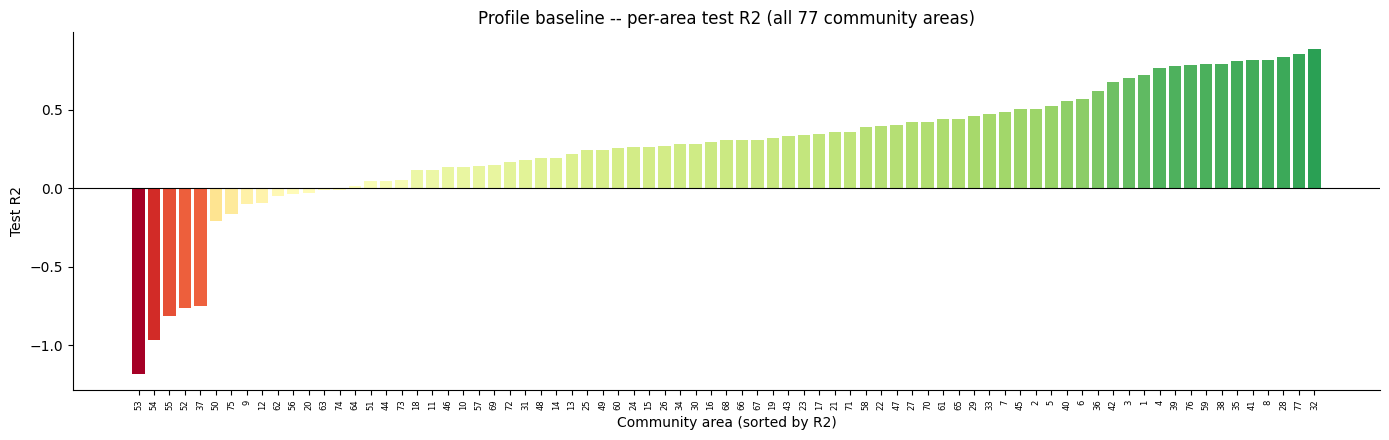

In [5]:
def profile_baseline(panel, groups, group_col="community_area"):
    results = []
    y_true_all, y_pred_all = [], []
    for g in groups:
        df_g = panel[panel[group_col] == g]
        tr = df_g[df_g["timestamp"] < TRAIN_END]
        te = df_g[df_g["timestamp"] >= TRAIN_END]
        profile = tr.groupby(["hour", "day_of_week"])["count"].mean()
        fallback = tr["count"].mean()
        keys = pd.MultiIndex.from_arrays([te["hour"], te["day_of_week"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true_ = te["count"].to_numpy(dtype=float)
        results.append({
            group_col: g,
            "median_demand": float(df_g["count"].median()),
            **metrics(y_true_, y_pred),
        })
        y_true_all.append(y_true_)
        y_pred_all.append(y_pred)
    per_group_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return per_group_df, pooled, y_true_concat, y_pred_concat


t0 = time.time()
baseline_results, pm_baseline, baseline_y_true, baseline_y_pred = profile_baseline(panel, ALL_AREAS)
baseline_results["community_area"] = baseline_results["community_area"].astype(int)
baseline_results["relative_mae"] = baseline_results["mae"] / (baseline_results["median_demand"] + 1)

print(f"Profile baseline, all 77 areas ({time.time()-t0:.0f}s)")
print(f"  Pooled  : R2={pm_baseline['r2']:.3f}  MAE={pm_baseline['mae']:.2f}  RMSE={pm_baseline['rmse']:.2f}")
print(f"  Per area: median R2={baseline_results['r2'].median():.3f}  "
      f"median MAE={baseline_results['mae'].median():.2f}  "
      f"median RMSE={baseline_results['rmse'].median():.2f}  "
      f"(areas with R2<0: {(baseline_results['r2']<0).sum()} of {len(baseline_results)})")

print("\nPer-area profile-baseline performance (sorted by R2, worst first):")
print(baseline_results.sort_values("r2").reset_index(drop=True).to_string(index=False))

# Diverging (R2 can be negative or positive) colouring, same RdYlGn scale used for the
# skill map further down, so the two figures read consistently.
plot_df = baseline_results.sort_values("r2").reset_index(drop=True)
vlim = max(0.5, plot_df["r2"].abs().max())
colors = plt.cm.RdYlGn((plot_df["r2"] + vlim) / (2 * vlim))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df)), plot_df["r2"], color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["community_area"], rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by R2)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-area test R2 (all 77 community areas)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Pooled LinearSVR — No Kernel

- One `LinearSVR`, fit on all 337,722 training rows (all 77 areas), evaluated pooled and
  per area.

In [6]:
t0 = time.time()
linear_model = Pipeline([
    ("prep", preprocess),
    ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42)),
])
linear_model.fit(train[ALL_COLS], np.log1p(train["count"]))
y_pred_linear = predict_counts(linear_model, test[ALL_COLS])
pm_linear = metrics(y_true, y_pred_linear)
res_linear = per_area_results(test, y_pred_linear)
res_linear["skill"] = skill_vs_baseline(res_linear)
res_linear["relative_mae"] = relative_mae(res_linear)

print_pooled_results(f"Pooled LinearSVR ({time.time()-t0:.0f}s)", pm_linear, res_linear)

Pooled LinearSVR (204s)
  Pooled  : R2=0.778  MAE=15.44  RMSE=67.64
  Per area: demand-weighted skill (headline)=-0.753  unweighted median skill=-0.032  median R2=0.259  (areas with negative skill: 48 of 77)


### 5.1 Feature Importance (LinearSVR Coefficients)

- `LinearSVR` is linear, so its coefficients on the standardized continuous features are
  directly interpretable as feature importance (larger |coefficient| = bigger effect on
  log-scale demand).
- Community-area dummy coefficients are a fixed log-demand offset per area relative to the
  reference area (area 1) -- shown separately (top/bottom 5 of 76), not comparable in
  magnitude to the continuous-feature coefficients since dummies aren't standardized.

In [ ]:
coefs = linear_model.named_steps["svm"].coef_
feature_coefs = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": coefs[:len(FEATURE_COLS)],
    "importance": np.abs(coefs[:len(FEATURE_COLS)]),
}).sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feature_coefs["feature"], feature_coefs["importance"], color=SEQUENTIAL_BLUE)
axes[0].set_xlabel("|coefficient| (standardized features)")
axes[0].set_title("LinearSVR feature importance (community area, pooled)")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(feature_coefs["feature"], feature_coefs["coefficient"],
             color=[SEQUENTIAL_BLUE if c >= 0 else "#e34948" for c in feature_coefs["coefficient"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("coefficient (sign = direction of effect on log-demand)")
axes[1].set_title("LinearSVR coefficient direction")
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Community-area fixed effects: which areas get the biggest adjustment vs. the reference area
area_coefs = pd.Series(coefs[len(FEATURE_COLS):], index=DUMMY_COLS).sort_values()
top_bottom = pd.concat([area_coefs.head(5), area_coefs.tail(5)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_bottom.index, top_bottom.to_numpy(),
        color=[SEQUENTIAL_BLUE if c >= 0 else "#e34948" for c in top_bottom])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Area fixed-effect coefficient (log-demand offset vs. reference area 1)")
ax.set_title("Largest area fixed effects (top/bottom 5 of 76)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.2 Demand-Weighted LinearSVR

- Section 8 finds `LinearSVR`'s demand-weighted skill is strongly negative (-0.75) -- it
  systematically underperforms the baseline in the highest-demand areas. Every area
  contributes equally many rows, so the shared coefficients end up fit mostly to the
  low-demand majority.
- **Fix**: refit with `sample_weight = sqrt(median_demand + 1)` per row -- the loss now
  actually prioritizes getting high-demand areas right, training the way the model is judged.

In [ ]:
train_weight = np.sqrt(train["community_area"].map(AREA_MEDIAN_DEMAND) + 1)

t0 = time.time()
linear_model_weighted = Pipeline([
    ("prep", preprocess),
    ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42)),
])
linear_model_weighted.fit(train[ALL_COLS], np.log1p(train["count"]), svm__sample_weight=train_weight)
y_pred_linear_weighted = predict_counts(linear_model_weighted, test[ALL_COLS])
pm_linear_weighted = metrics(y_true, y_pred_linear_weighted)
res_linear_weighted = per_area_results(test, y_pred_linear_weighted)
res_linear_weighted["skill"] = skill_vs_baseline(res_linear_weighted)
res_linear_weighted["relative_mae"] = relative_mae(res_linear_weighted)

print_pooled_results(f"Pooled LinearSVR, demand-weighted ({time.time()-t0:.0f}s)", pm_linear_weighted, res_linear_weighted)

# Before/after: does weighting fix the high-demand underperformance?
before = res_linear.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)
after = res_linear_weighted.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df, title in [(axes[0], before, "Unweighted"), (axes[1], after, "Demand-weighted")]:
    colors = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in df["skill"]]
    ax.scatter(df["median_demand"] + 1, df["skill"], color=colors, s=25)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Median demand per area (log scale, +1)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Skill vs. profile baseline")
plt.suptitle("Does demand-weighting fix high-demand underperformance?")
plt.tight_layout()
plt.show()

### 5.3 Outcome: Weighting Alone Doesn't Solve It

| | Unweighted | Weighted |
|---|---|---|
| Demand-weighted skill | -0.75 | -0.61 |
| Unweighted median skill | -0.03 | -0.12 |
| Negative-skill areas | 48/77 | 67/77 |

- Weighting improves the headline metric but hurts the majority of areas (more negative-skill
  areas, worse median skill) -- a real trade-off, not a clean fix.
- **Likely root cause**: `expm1` back-transform amplifies log-scale error multiplicatively --
  a small `log1p`-space miss becomes a huge absolute error exactly where demand is largest.
  The baseline predicts directly in raw-count space and never pays this penalty.
- **Decision**: `LinearSVR` (plain, unweighted, full data) is used as the SVM entry for the
  rest of this notebook -- not because it solves the problem, but because weighting doesn't
  either, and unweighted at least doesn't hurt the majority of areas. Two bigger structural
  changes (demand-tiering redone, and per-area models fit above a demand threshold) are
  explored separately in section 9 rather than adopted as the default here.

## 6. Kernel Comparison

- Exact kernel SVR is O(n^2)-O(n^3) in training rows — infeasible on 337,722 full rows.
- Compared on a **10,000-row random subsample**, evaluated against the full test set.
- **Informational only** — section 7 shows subsample-tuned results are unreliable.

In [ ]:
rng = np.random.RandomState(42)
sub_idx = rng.choice(train.index, size=10000, replace=False)
train_sub = train.loc[sub_idx]

candidates = {
    "no kernel (LinearSVR)": LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42),
    "linear (SVR)":          SVR(kernel="linear",  C=100, epsilon=0.1),
    "poly, degree 2":        SVR(kernel="poly",    degree=2, C=100, gamma="scale", epsilon=0.1),
    "rbf":                   SVR(kernel="rbf",     C=100, gamma="scale", epsilon=0.1),
    "sigmoid":               SVR(kernel="sigmoid", C=100, gamma="scale", epsilon=0.1),
}

kernel_rows = []
for name, svm in candidates.items():
    t0 = time.time()
    m = Pipeline([("prep", preprocess), ("svm", svm)])
    m.fit(train_sub[ALL_COLS], np.log1p(train_sub["count"]))
    y_pred = predict_counts(m, test[ALL_COLS])
    kernel_rows.append({"kernel": name, **metrics(y_true, y_pred), "fit_seconds": round(time.time() - t0, 1)})

kernel_df = pd.DataFrame(kernel_rows).sort_values("r2", ascending=False)
print("Kernel comparison -- 10,000-row train subsample, full test set, pooled metrics:")
print(kernel_df.to_string(index=False))


- **Methodological trap, caught early**: scaling the dummy columns flipped which kernel
  looked best — RBF looked best (R2=0.85) with dummies scaled; poly degree 2 looked best
  (R2=0.88) once dummies were left unscaled (RBF dropped to R2=0.74).
- RBF's distance-based kernel was dominated by the inflated dummy scale; poly's dot-product
  kernel was far less sensitive.
- Sigmoid is unstable regardless of scaling.

## 7. Hyperparameter Tuning — GridSearchCV

- Tuning poly (the naive section-6 winner) properly with `GridSearchCV` + `TimeSeriesSplit(3)`,
  same 20,000-row budget, a different draw than section 6.

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)
rng2 = np.random.RandomState(42)
sub_idx2 = np.sort(rng2.choice(train.index, size=10000, replace=False))  # sorted: keep time order for TimeSeriesSplit
train_sub2 = train.loc[sub_idx2]

poly_param_grid = {"svm__C": [1, 10, 100], "svm__degree": [2, 3], "svm__gamma": ["scale"]}
t0 = time.time()
gs_poly = GridSearchCV(
    Pipeline([("prep", preprocess), ("svm", SVR(kernel="poly", epsilon=0.1))]),
    poly_param_grid, cv=tscv, scoring="r2", n_jobs=-1,
)
gs_poly.fit(train_sub2[FEATURE_COLS + DUMMY_COLS], np.log1p(train_sub2["count"]))
y_pred_poly = predict_counts(gs_poly, test[ALL_COLS])
pm_poly = metrics(y_true, y_pred_poly)
res_poly = per_area_results(test, y_pred_poly)
res_poly["skill"] = skill_vs_baseline(res_poly)
res_poly["relative_mae"] = relative_mae(res_poly)

print(f"Tuned poly ({time.time()-t0:.0f}s): best_params={gs_poly.best_params_}  "
      f"best_cv_r2={gs_poly.best_score_:.3f}")
print_pooled_results("", pm_poly, res_poly)

rbf_param_grid = {"svm__C": [10, 100], "svm__gamma": ["scale", 0.01]}
t0 = time.time()
gs_rbf = GridSearchCV(
    Pipeline([("prep", preprocess), ("svm", SVR(kernel="rbf", epsilon=0.1))]),
    rbf_param_grid, cv=tscv, scoring="r2", n_jobs=-1,
)
gs_rbf.fit(train_sub2[FEATURE_COLS + DUMMY_COLS], np.log1p(train_sub2["count"]))
y_pred_rbf = predict_counts(gs_rbf, test[ALL_COLS])
pm_rbf = metrics(y_true, y_pred_rbf)
res_rbf = per_area_results(test, y_pred_rbf)
res_rbf["skill"] = skill_vs_baseline(res_rbf)
res_rbf["relative_mae"] = relative_mae(res_rbf)

print(f"\nTuned RBF ({time.time()-t0:.0f}s): best_params={gs_rbf.best_params_}  "
      f"best_cv_r2={gs_rbf.best_score_:.3f}")
print_pooled_results("", pm_rbf, res_rbf)

- Tuned poly: `best_cv_r2=0.088` (weak) -> **R2=-0.032 on the test set**, worse than baseline
  for 62 of 77 areas — despite looking excellent (R2=0.875) on the single untuned draw in
  section 6.
- Tuned RBF: more moderate (test R2=0.792) but still weak in CV (`best_cv_r2=-0.079`).
- **Conclusion**: kernel-SVR tuning from a small subsample of a much larger dataset is
  high-variance and unreliable here. `LinearSVR` (full data, no subsampling) has no such
  instability and is the model carried into section 8.

## 8. Results — Model Comparison

- None of the `LinearSVR` variants beat the profile baseline on demand-weighted skill (5.1-5.3)
  -- plain **unweighted `LinearSVR`** (per 5.3) is used below as the SVM entry.
- Tuned kernel models are shown for completeness, not as an alternative recommendation.

In [ ]:
comparison_df = pd.DataFrame([
    {"Model": "Profile baseline", "Demand-weighted skill": 0.000, "Median skill": 0.000,
     "Median relative MAE": baseline_results["relative_mae"].median(),
     "Pooled R2": pm_baseline["r2"], "Median R2/area": baseline_results["r2"].median()},
    {"Model": "LinearSVR (full data, no kernel)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_linear), "Median skill": res_linear["skill"].median(),
     "Median relative MAE": res_linear["relative_mae"].median(),
     "Pooled R2": pm_linear["r2"], "Median R2/area": res_linear["r2"].median()},
    {"Model": "LinearSVR (demand-weighted)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_linear_weighted), "Median skill": res_linear_weighted["skill"].median(),
     "Median relative MAE": res_linear_weighted["relative_mae"].median(),
     "Pooled R2": pm_linear_weighted["r2"], "Median R2/area": res_linear_weighted["r2"].median()},
    {"Model": "RBF, tuned (10k subsample)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_rbf), "Median skill": res_rbf["skill"].median(),
     "Median relative MAE": res_rbf["relative_mae"].median(),
     "Pooled R2": pm_rbf["r2"], "Median R2/area": res_rbf["r2"].median()},
    {"Model": "Poly, tuned (10k subsample)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_poly), "Median skill": res_poly["skill"].median(),
     "Median relative MAE": res_poly["relative_mae"].median(),
     "Pooled R2": pm_poly["r2"], "Median R2/area": res_poly["r2"].median()},
]).round(3)
print("Headline column is demand-weighted skill (the fleet is deployed mostly to high-demand")
print("areas, so those areas matter most); unweighted median skill and R2/MAE are supporting detail.")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
chart_df = comparison_df.set_index("Model")["Demand-weighted skill"]
colors_cmp = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in chart_df]
axes[0].barh(chart_df.index, chart_df.to_numpy(), color=colors_cmp)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Demand-weighted skill vs. profile baseline")
axes[0].set_title("Skill (relative to baseline)")
axes[0].spines[["top", "right"]].set_visible(False)

rmae_df = comparison_df.set_index("Model")["Median relative MAE"]
axes[1].barh(rmae_df.index, rmae_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[1].set_xlabel("Median relative MAE (MAE / median demand)")
axes[1].set_title("Relative MAE (absolute, no baseline)")
axes[1].spines[["top", "right"]].set_visible(False)
plt.suptitle("Model comparison -- community area")
plt.tight_layout()
plt.show()

### 8.0 Actual vs. Predicted (Test Set)

- Same five models as the comparison table above, same test set, same axes -- a tighter
  cluster along the dashed diagonal means better predictions.
- Plotted on `log1p` scale (a 5,000-point random sample, for a readable scatter): demand spans
  ~1000x across rows, so a raw-scale plot would be unreadable.

In [ ]:
models_to_plot = [
    ("Profile baseline", baseline_y_pred),
    ("LinearSVR", y_pred_linear),
    ("LinearSVR (weighted)", y_pred_linear_weighted),
    ("RBF, tuned", y_pred_rbf),
    ("Poly, tuned", y_pred_poly),
]

rng_viz = np.random.RandomState(0)
sample_n = min(5000, len(y_true))
sample_idx = rng_viz.choice(len(y_true), size=sample_n, replace=False)
log_true = np.log1p(y_true)
lims = [0, log_true.max()]

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(22, 4.5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, models_to_plot):
    log_pred = np.log1p(y_pred)
    ax.scatter(log_true[sample_idx], log_pred[sample_idx], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims, lims, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle(f"Actual vs. predicted demand -- test set, {sample_n:,}-point sample "
             f"(dashed = perfect prediction)")
plt.tight_layout()
plt.show()

### 8.1 Per-Area Performance

- **Two complementary scores**, both comparable across areas of very different demand:
  - **Skill** -- relative to the profile baseline (competitive: does the model beat a smart
    per-area baseline?).
  - **Relative MAE** (`mae / (median_demand + 1)`) -- absolute, no baseline involved (how
    big are the errors relative to what actually happens in that area?).
- Shown for the plain **unweighted LinearSVR** (per 5.3). The two metrics
  don't have to agree -- an area can look bad on one and fine on the other.

In [ ]:
res_linear_by_skill = res_linear.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("skill").reset_index(drop=True)
colors_skill = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_linear_by_skill["skill"]]

res_linear_by_rmae = res_linear.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("relative_mae", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].bar(range(len(res_linear_by_skill)), res_linear_by_skill["skill"], color=colors_skill, width=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(range(len(res_linear_by_skill)))
axes[0].set_xticklabels(res_linear_by_skill["community_area"], rotation=90, fontsize=6)
axes[0].set_xlabel("Community area (sorted by skill)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill (relative to baseline)")

axes[1].bar(range(len(res_linear_by_rmae)), res_linear_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, width=0.8)
axes[1].set_xticks(range(len(res_linear_by_rmae)))
axes[1].set_xticklabels(res_linear_by_rmae["community_area"], rotation=90, fontsize=6)
axes[1].set_xlabel("Community area (sorted by relative MAE, worst first)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE (absolute, no baseline)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("LinearSVR (unweighted) -- per-area performance, two views")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(res_linear_by_skill["median_demand"] + 1, res_linear_by_skill["skill"], color=colors_skill, s=25)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlabel("Median demand per area (log scale, +1)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill vs. area demand")

axes[1].scatter(res_linear_by_rmae["median_demand"] + 1, res_linear_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, s=25)
axes[1].set_xscale("log")
axes[1].set_xlabel("Median demand per area (log scale, +1)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE vs. area demand")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Per-area skill map for `LinearSVR` (plain, unweighted, full pooled data) -- no areas excluded.

In [ ]:
community_areas_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
community_areas_gdf["area_numbe"] = community_areas_gdf["area_numbe"].astype(int)

gdf_skill = community_areas_gdf.merge(
    res_linear[["community_area", "skill"]],
    left_on="area_numbe", right_on="community_area", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=0.5, legend=True,
               legend_kwds={"label": "Test skill vs. profile baseline (pooled LinearSVR, 4h)", "shrink": 0.6},
               edgecolor="white", linewidth=0.4)
ctx.add_basemap(ax, crs=gdf_skill.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title("Pooled LinearSVR -- skill vs. baseline per community area (all 77 areas)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Demand Tiering & Per-Area Models (4h, Community Area)

Two further structural attempts at the section 5.3 problem, kept separate from the main flow
above -- exploratory, "we tried this," not a replacement for the plain `LinearSVR` used as the
SVM entry through section 8:

- **9.1**: redo the demand-tiered `LinearSVR` (3 pooled models by demand tercile).
- **9.2**: per-area models above a demand threshold -- one model fit per included area
  (threshold-based selection, per-area fitting, kernel tuning), no rolling-origin backtest.

### 9.0 Area Demand Overview — Which Areas Go Where

Both groupings below are derived from the same `AREA_MEDIAN_DEMAND` values computed in
section 3, so this is the single reference chart for "which area falls into which group":

- **Demand tiers** (9.1): equal-count terciles (low/medium/high), light-to-dark blue.
- **Per-area threshold = 10** (9.2): dashed line -- areas above it get their own model;
  areas below it do not (see 9.2 for what happens to them instead).

In [ ]:
DEMAND_TIER = pd.qcut(AREA_MEDIAN_DEMAND, 3, labels=["low", "medium", "high"])
DEMAND_THRESHOLD = 10  # trips/window median demand -- below this, target variance is too
                        # low for a regression model to beat the mean

area_demand_sorted = AREA_MEDIAN_DEMAND.sort_values()
tier_sorted = DEMAND_TIER.reindex(area_demand_sorted.index)
tier_color_map = {"low": "#9ec5f4", "medium": SEQUENTIAL_BLUE, "high": "#0d366b"}
bar_colors = tier_sorted.map(tier_color_map)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(area_demand_sorted)), area_demand_sorted.to_numpy() + 1, color=bar_colors, width=0.8)
ax.set_yscale("log")
ax.set_xticks(range(len(area_demand_sorted)))
ax.set_xticklabels(area_demand_sorted.index, rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by median demand)")
ax.set_ylabel("Median demand + 1 (log scale)")
ax.set_title("Median demand per area -- tiers (9.1) and per-area threshold (9.2)")
ax.spines[["top", "right"]].set_visible(False)

threshold_line = ax.axhline(DEMAND_THRESHOLD, color="#e34948", linewidth=1.2, linestyle="--",
                             label=f"Per-area threshold = {DEMAND_THRESHOLD} trips/window (9.2)")
legend_handles = [
    Patch(facecolor=tier_color_map["low"], label="Low tier (9.1)"),
    Patch(facecolor=tier_color_map["medium"], label="Medium tier (9.1)"),
    Patch(facecolor=tier_color_map["high"], label="High tier (9.1)"),
    threshold_line,
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 9.1 Redo: Demand-Tiered LinearSVR

- Same construction as before removal from section 5: split the 77 areas into 3 demand
  terciles (low/medium/high) and fit a separate pooled `LinearSVR` per tier.

In [ ]:
# DEMAND_TIER computed in the area-overview cell above
train_tier = train["community_area"].map(DEMAND_TIER)
test_tier = test["community_area"].map(DEMAND_TIER)

y_pred_tiered = pd.Series(index=test.index, dtype=float)
t0 = time.time()
for tier in ["low", "medium", "high"]:
    tr_t = train[train_tier == tier]
    te_t = test[test_tier == tier]
    m = Pipeline([("prep", clone(preprocess)), ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42))])
    m.fit(tr_t[ALL_COLS], np.log1p(tr_t["count"]))
    y_pred_tiered.loc[te_t.index] = predict_counts(m, te_t[ALL_COLS])
    print(f"  {tier:6s}: {tr_t['community_area'].nunique()} areas, {len(tr_t):,} train rows")

y_pred_tiered = y_pred_tiered.to_numpy()
pm_tiered = metrics(y_true, y_pred_tiered)
res_tiered = per_area_results(test, y_pred_tiered)
res_tiered["skill"] = skill_vs_baseline(res_tiered)
res_tiered["relative_mae"] = relative_mae(res_tiered)

print_pooled_results(f"Pooled LinearSVR, demand-tiered ({time.time()-t0:.0f}s)", pm_tiered, res_tiered)

# vs. the plain unweighted fit from section 5
before = res_linear.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)
after = res_tiered.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df, title in [(axes[0], before, "Unweighted (1 shared model)"), (axes[1], after, "Demand-tiered (3 models)")]:
    colors = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in df["skill"]]
    ax.scatter(df["median_demand"] + 1, df["skill"], color=colors, s=25)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Median demand per area (log scale, +1)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Skill vs. profile baseline")
plt.suptitle("Does demand-tiering fix high-demand underperformance?")
plt.tight_layout()
plt.show()

### 9.2 Per-Area Models Above a Demand Threshold

- A per-area model is only meaningful where there's enough demand signal -- below the
  threshold the target has so little variance that no regression model can beat the mean
  (R2 goes negative although the absolute error is under 1 trip).
- **Threshold**: median >= 10 trips/window.
- **The 57 areas below the threshold are not modeled here at all** -- no per-area model is
  fit for them in this section. They're already covered elsewhere in this notebook: the
  profile baseline (section 4) and the pooled `LinearSVR` variants (sections 5, 9.1) produce
  predictions for all 77 areas, including these. In a deployment setting, these areas would
  fall back to whichever of those already covers them -- there's no dedicated per-area model
  for a unit with too little signal to fit one meaningfully.
- Feature set: this notebook's 17 features (includes the second harmonic), same as sections
  1-8.
- **No rolling-origin backtest** -- single chronological holdout, same as the rest of this
  notebook.

In [ ]:
# DEMAND_THRESHOLD computed in the area-overview cell above
included_areas = AREA_MEDIAN_DEMAND[AREA_MEDIAN_DEMAND >= DEMAND_THRESHOLD].index.tolist()
excluded_areas = AREA_MEDIAN_DEMAND[AREA_MEDIAN_DEMAND < DEMAND_THRESHOLD].index.tolist()
print(f"threshold = median >= {DEMAND_THRESHOLD} trips/window -> "
      f"{len(included_areas)} areas included, {len(excluded_areas)} excluded")
print(f"  included: {included_areas}")

#### 9.2.1 Default Per-Area Models (LinearSVR + RBF)

- One model per included area, each fit only on that area's own rows (chronological split,
  same `TRAIN_END`) -- avoids the pooled model's scale-domination problem structurally,
  since no area shares coefficients with any other.

In [ ]:
def train_per_area(panel, areas, make_model, feature_cols=FEATURE_COLS):
    """Fit one model per area (chronological split); returns per-area results + fitted models."""
    results, models = [], {}
    y_true_all, y_pred_all = [], []
    for area in areas:
        df_area = panel[panel["community_area"] == area]
        tr = df_area[df_area["timestamp"] < TRAIN_END]
        te = df_area[df_area["timestamp"] >= TRAIN_END]
        model = make_model()
        model.fit(tr[feature_cols], np.log1p(tr["count"]))
        y_true = te["count"].to_numpy(dtype=float)
        y_pred = predict_counts(model, te[feature_cols])
        results.append({"community_area": area, **metrics(y_true, y_pred)})
        models[area] = model
        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
    results_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return results_df, models, pooled, y_true_concat, y_pred_concat


t0 = time.time()
res_pa_linear, models_pa_linear, pm_pa_linear, y_true_pa_linear, y_pred_pa_linear = train_per_area(
    panel, included_areas,
    lambda: Pipeline([("scaler", StandardScaler()), ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42))]),
)
res_pa_linear["skill"] = skill_vs_baseline(res_pa_linear)
res_pa_linear["relative_mae"] = relative_mae(res_pa_linear)
print_pooled_results(f"LinearSVR per area, {len(included_areas)} areas ({time.time()-t0:.0f}s)", pm_pa_linear, res_pa_linear)

t0 = time.time()
res_pa_rbf, models_pa_rbf, pm_pa_rbf, y_true_pa_rbf, y_pred_pa_rbf = train_per_area(
    panel, included_areas,
    lambda: Pipeline([("scaler", StandardScaler()), ("svm", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))]),
)
res_pa_rbf["skill"] = skill_vs_baseline(res_pa_rbf)
res_pa_rbf["relative_mae"] = relative_mae(res_pa_rbf)
print_pooled_results(f"RBF SVR per area, default params, {len(included_areas)} areas ({time.time()-t0:.0f}s)", pm_pa_rbf, res_pa_rbf)

#### 9.2.2 Hyperparameter Tuning — GridSearchCV per Area

- Kept despite the runtime cost (roughly 20-45 minutes for the RBF grid across ~20 areas with
  two years of training data) -- exact kernel SVR is feasible per-area (~4,400 training
  rows/area) in a way it isn't for the full pooled dataset (sections 6-7).
- `TimeSeriesSplit(3)`, same as the tuning in section 7.

In [ ]:
def gridsearch_per_area(panel, areas, base_estimator, param_grid, feature_cols=FEATURE_COLS):
    tscv_pa = TimeSeriesSplit(n_splits=3)
    results, models = [], {}
    y_true_all, y_pred_all = [], []
    for area in areas:
        df_area = panel[panel["community_area"] == area]
        tr = df_area[df_area["timestamp"] < TRAIN_END]
        te = df_area[df_area["timestamp"] >= TRAIN_END]
        gs = GridSearchCV(
            Pipeline([("scaler", StandardScaler()), ("svm", base_estimator)]),
            param_grid, cv=tscv_pa, scoring="r2", n_jobs=-1,
        )
        gs.fit(tr[feature_cols], np.log1p(tr["count"]))
        y_true = te["count"].to_numpy(dtype=float)
        y_pred = predict_counts(gs, te[feature_cols])
        results.append({
            "community_area": area,
            "best_params": {k.replace("svm__", ""): v for k, v in gs.best_params_.items()},
            "cv_r2": round(gs.best_score_, 4),
            **metrics(y_true, y_pred),
        })
        models[area] = gs.best_estimator_
        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
    results_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return results_df, models, pooled, y_true_concat, y_pred_concat


linear_param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100], "svm__epsilon": [0.01, 0.1]}
rbf_param_grid    = {"svm__C": [10, 100, 1000], "svm__gamma": ["scale", 0.01], "svm__epsilon": [0.1]}

t0 = time.time()
res_pa_linear_tuned, models_pa_linear_tuned, pm_pa_linear_tuned, y_true_pa_linear_tuned, y_pred_pa_linear_tuned = gridsearch_per_area(
    panel, included_areas, LinearSVR(max_iter=20000, random_state=42), linear_param_grid)
res_pa_linear_tuned["skill"] = skill_vs_baseline(res_pa_linear_tuned)
res_pa_linear_tuned["relative_mae"] = relative_mae(res_pa_linear_tuned)
print_pooled_results(f"Tuned LinearSVR per area ({time.time()-t0:.0f}s)", pm_pa_linear_tuned, res_pa_linear_tuned)

t0 = time.time()
res_pa_rbf_tuned, models_pa_rbf_tuned, pm_pa_rbf_tuned, y_true_pa_rbf_tuned, y_pred_pa_rbf_tuned = gridsearch_per_area(
    panel, included_areas, SVR(kernel="rbf"), rbf_param_grid)
res_pa_rbf_tuned["skill"] = skill_vs_baseline(res_pa_rbf_tuned)
res_pa_rbf_tuned["relative_mae"] = relative_mae(res_pa_rbf_tuned)
print_pooled_results(f"Tuned RBF SVR per area ({time.time()-t0:.0f}s)", pm_pa_rbf_tuned, res_pa_rbf_tuned)

#### 9.2.3 Results — Default vs. Tuned, Per-Area

In [ ]:
pa_summary = pd.DataFrame({
    "Model": ["LinearSVR default", "LinearSVR tuned", "RBF SVR default", "RBF SVR tuned"],
    "Demand-weighted skill": [
        weighted_skill_vs_baseline(res_pa_linear), weighted_skill_vs_baseline(res_pa_linear_tuned),
        weighted_skill_vs_baseline(res_pa_rbf),     weighted_skill_vs_baseline(res_pa_rbf_tuned),
    ],
    "Median skill": [
        res_pa_linear["skill"].median(), res_pa_linear_tuned["skill"].median(),
        res_pa_rbf["skill"].median(),    res_pa_rbf_tuned["skill"].median(),
    ],
    "Median relative MAE": [
        res_pa_linear["relative_mae"].median(), res_pa_linear_tuned["relative_mae"].median(),
        res_pa_rbf["relative_mae"].median(),    res_pa_rbf_tuned["relative_mae"].median(),
    ],
    "Pooled R2": [pm_pa_linear["r2"], pm_pa_linear_tuned["r2"], pm_pa_rbf["r2"], pm_pa_rbf_tuned["r2"]],
}).round(3)
print(f"Per-area models, {len(included_areas)} areas above threshold (4h, chronological test set):")
print(pa_summary.to_string(index=False))

merged = (
    res_pa_rbf[["community_area", "skill"]].rename(columns={"skill": "default"})
    .merge(res_pa_rbf_tuned[["community_area", "skill"]].rename(columns={"skill": "tuned"}), on="community_area")
    .sort_values("tuned")
)
fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(merged))
ax.barh(x - 0.19, merged["default"], 0.38, label="RBF default", color="#e34948")
ax.barh(x + 0.19, merged["tuned"],   0.38, label="RBF tuned",   color=SEQUENTIAL_BLUE)
ax.set_yticks(x)
ax.set_yticklabels(merged["community_area"].astype(str), fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Skill vs. profile baseline")
ax.set_title("RBF SVR per area -- default vs tuned")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#### 9.2.4 Actual vs. Predicted (Per-Area Models)

- Same style as section 8's chart, pooled across the included areas' test rows.

In [ ]:
pa_models_to_plot = [
    ("LinearSVR default", y_true_pa_linear, y_pred_pa_linear),
    ("LinearSVR tuned", y_true_pa_linear_tuned, y_pred_pa_linear_tuned),
    ("RBF default", y_true_pa_rbf, y_pred_pa_rbf),
    ("RBF tuned", y_true_pa_rbf_tuned, y_pred_pa_rbf_tuned),
]

rng_viz_pa = np.random.RandomState(0)
lims_pa = [0, max(np.log1p(yt).max() for _, yt, _ in pa_models_to_plot)]

fig, axes = plt.subplots(1, len(pa_models_to_plot), figsize=(18, 4.5), sharex=True, sharey=True)
for ax, (name, yt, yp) in zip(axes, pa_models_to_plot):
    n_sample = min(5000, len(yt))
    idx = rng_viz_pa.choice(len(yt), size=n_sample, replace=False)
    ax.scatter(np.log1p(yt)[idx], np.log1p(yp)[idx], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims_pa, lims_pa, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims_pa)
    ax.set_ylim(lims_pa)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle("Actual vs. predicted demand -- per-area models, pooled across included areas")
plt.tight_layout()
plt.show()

### 9.3 Conclusion — High-Demand Areas Are the Hard Case Throughout

Real numbers from this section (20 areas above the threshold, median demand 10-553):

| Model | Demand-weighted skill | Median skill | Areas skill < 0 |
|---|---|---|---|
| LinearSVR default | -0.100 | -0.072 | 14 of 20 |
| LinearSVR tuned | -0.113 | -0.093 | 14 of 20 |
| RBF default | -0.111 | -0.140 | 20 of 20 |
| **RBF tuned** | **+0.023** | -0.008 | 12 of 20 |

- **Even with a dedicated model per area -- no pooling, no shared coefficients, nothing left
  to dilute the fit -- most configurations still lose to the profile baseline.** That rules
  out cross-area dilution as the *whole* story (section 5.3's original hypothesis): removing
  pooling entirely doesn't fix it either.
- **Tuned RBF is the only configuration in this entire notebook -- pooled or per-area -- that
  beats the baseline on demand-weighted skill**, and only barely (+0.023, 12 of 20 areas still
  individually negative). Full kernel flexibility plus per-area hyperparameter tuning helps,
  but doesn't decisively solve it.
- **This is consistent with the pattern found across every earlier section**: section 8.1's
  skill-vs-demand scatter already showed skill declining as area demand increases, for the
  pooled model. Here, restricted to only the 20 *highest*-demand areas with dedicated models,
  the struggle is still visible -- high demand is the hard case whether or not pooling is
  involved.
- **Practical read**: the profile baseline -- a simple per-(hour, weekday) average -- is a
  surprisingly strong, hard-to-beat reference specifically where demand is largest. Every
  modeling approach tried in this notebook (pooled unweighted, demand-weighted, demand-tiered,
  per-area default, per-area tuned) does relatively better against baseline on low/medium
  demand areas than on the highest-demand ones.

## 10. Shortfalls & Honest Limitations

- **Pooled log-scale regression struggles with extreme-demand areas** (section 5.3):
  demand-weighting doesn't close the gap to baseline for the 2-3 highest-demand areas --
  likely `expm1` back-transform error amplification. Demand-tiering and per-area models
  (section 9) are further attempts at this, not a resolved fix.
- **Kernel-SVR tuning instability** (section 7): result quality depends heavily on which
  subsample/validation draw judged it — a limitation of subsample-then-tune, not of kernel
  SVR itself.
- **Dummy scaling is not cosmetic**: it changed runtime (5x) and which kernel looked best.
- **Fixed effects assume every unit is seen in training** — holds here (same areas in train
  and test) but would break for a genuinely unseen spatial unit.
- **Rolling-origin backtest and 1-hour resolution** not yet done — natural next steps.

## 11. Outlook: Census Tract Level & Other Resolutions

Implemented separately in `03.06_prediction_svm_tract.ipynb`, so this notebook stays
community-area / 4h only. Summary (full detail in `03.06`):

- **Panel construction**: same logic as section 2, joined to `census_tracts_chicago.geojson`.
- **Spatial identity in two layers**: reuse the 77 community-area dummies (coarse) + add
  tract-level covariates -- POI count, tract area, distance to downtown/O'Hare (fine) --
  rather than ~800 raw tract dummies.
- **Scale**: ~800 tracts x 5,292 windows ~= 4.2M rows, ~10x this panel.
- **No repeated kernel-tuning pass at tract level**: growing the training set ~10x doesn't
  help kernel SVR -- the feasible tuning subsample size is unchanged, so it covers an even
  thinner slice of the data. `LinearSVR` (full data) is the primary SVM entry there too, same
  as here.
- Reuses this notebook's panel-building/evaluation code directly (helper functions with
  `group_col`/`baseline_df` parameters, built for exactly this reuse).